In [2]:
from google.colab import files
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json


uploaded = files.upload()

aircrafts = pd.read_excel("aircrafts_data.xlsx")
airports  = pd.read_excel("airports_data.xlsx")
bookings  = pd.read_excel("bookings.xlsx")
boarding  = pd.read_excel("boarding_passes.xlsx")
flights   = pd.read_excel("flights.xlsx")
tickets   = pd.read_excel("tickets.xlsx")
tf        = pd.read_excel("ticket_flights.xlsx")
seats     = pd.read_excel("seats.xlsx")
reviews   = pd.read_excel("reviews.xlsx")

Saving aircrafts_data.xlsx to aircrafts_data.xlsx
Saving airports_data.xlsx to airports_data.xlsx
Saving boarding_passes.xlsx to boarding_passes.xlsx
Saving bookings.xlsx to bookings.xlsx
Saving flights.xlsx to flights.xlsx
Saving reviews.xlsx to reviews.xlsx
Saving seats.xlsx to seats.xlsx
Saving ticket_flights.xlsx to ticket_flights.xlsx
Saving tickets.xlsx to tickets.xlsx


In [3]:
for name, df in [("aircrafts", aircrafts), ("airports", airports),
                 ("bookings", bookings), ("boarding", boarding),
                 ("flights", flights), ("tickets", tickets),
                 ("tf", tf), ("seats", seats), ("reviews", reviews)]:
     print(f"\n{'='*40}")
     print(f"Table: {name}")
     print(df.info())


Table: aircrafts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   aircraft_code  9 non-null      object
 1   model          9 non-null      object
 2   range          9 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 348.0+ bytes
None

Table: airports
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   airport_code  104 non-null    object
 1   airport_name  104 non-null    object
 2   city          104 non-null    object
 3   coordinates   104 non-null    object
dtypes: object(4)
memory usage: 3.4+ KB
None

Table: bookings
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262788 entries, 0 to 262787
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------       

In [4]:
# Drop Empty Columns From Bookings
bookings = bookings.drop(columns=["Unnamed: 0", "Unnamed: 1"])
print(bookings.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262788 entries, 0 to 262787
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   book_ref      262788 non-null  object
 1   book_date     262788 non-null  object
 2   total_amount  262788 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 6.0+ MB
None


In [5]:
for name, df in [("aircrafts", aircrafts), ("airports", airports),
                 ("bookings", bookings), ("boarding", boarding),
                 ("flights", flights), ("tickets", tickets),
                 ("tf", tf), ("seats", seats), ("reviews", reviews)]:
    null_count = df.isnull().sum()
    null_pct   = (df.isnull().sum() / len(df) * 100).round(2)
    null_df    = pd.DataFrame({"null_count": null_count, "null_%": null_pct})
    null_df    = null_df[null_df["null_count"] > 0]

    print(f"\n{'='*40}")
    print(f"Table: {name}")
    if null_df.empty:
        print("  No nulls found")
    else:
        print(null_df)


Table: aircrafts
  No nulls found

Table: airports
  No nulls found

Table: bookings
  No nulls found

Table: boarding
  No nulls found

Table: flights
  No nulls found

Table: tickets
  No nulls found

Table: tf
  No nulls found

Table: seats
  No nulls found

Table: reviews
  No nulls found


In [6]:
# Check Delayed Flights With Null Actual Times
delayed_null = flights[(flights["status"] == "Delayed") & (flights["actual_departure"] == "\\N")]
print(f"Delayed flights with null actual_departure: {len(delayed_null)}")

Delayed flights with null actual_departure: 41


In [7]:
# Drop Delayed Flights With Null Actual Times
flights = flights[~((flights["status"] == "Delayed") & (flights["actual_departure"] == "\\N"))]
print(f"Flights after drop: {len(flights):,}")

Flights after drop: 33,080


In [8]:
# Replace \N Then Convert To Datetime
flights["actual_departure"] = flights["actual_departure"].replace("\\N", pd.NaT)
flights["actual_arrival"]   = flights["actual_arrival"].replace("\\N", pd.NaT)

flights["scheduled_arrival"]  = pd.to_datetime(flights["scheduled_arrival"])
flights["scheduled_departure"] = pd.to_datetime(flights["scheduled_departure"])
flights["actual_departure"]    = pd.to_datetime(flights["actual_departure"])
flights["actual_arrival"]      = pd.to_datetime(flights["actual_arrival"])
print(flights[["actual_departure", "actual_arrival"]].isnull().sum())

actual_departure    16307
actual_arrival      16365
dtype: int64


In [9]:
# Check If Arrived Flights Are Actually Delayed
arrived = flights[flights["status"] == "Arrived"].copy()
arrived["delay_minutes"] = (arrived["actual_arrival"] - arrived["scheduled_arrival"]).dt.total_seconds() / 60

print(arrived["delay_minutes"].describe())
print(f"\nOn time or early: {len(arrived[arrived['delay_minutes'] <= 0])}")
print(f"Delayed: {len(arrived[arrived['delay_minutes'] > 0])}")

count    16707.000000
mean        12.202430
std         41.447011
min        -12.000000
25%          2.000000
50%          3.000000
75%          5.000000
max        277.000000
Name: delay_minutes, dtype: float64

On time or early: 1814
Delayed: 14893


In [10]:
# Split Arrived Into Delayed And On Time
flights.loc[(flights["status"] == "Arrived") & (arrived["delay_minutes"] > 0), "status"] = "Delayed"
flights.loc[(flights["status"] == "Arrived") & (arrived["delay_minutes"] <= 0), "status"] = "On Time"
print(flights["status"].value_counts())

status
Scheduled    15383
Delayed      14893
On Time       2332
Cancelled      414
Departed        58
Name: count, dtype: int64


In [11]:
# Convert All Date Columns To Datetime
flights["scheduled_departure"]  = pd.to_datetime(flights["scheduled_departure"])
flights["scheduled_arrival"]    = pd.to_datetime(flights["scheduled_arrival"])
flights["actual_departure"]     = pd.to_datetime(flights["actual_departure"])
flights["actual_arrival"]       = pd.to_datetime(flights["actual_arrival"])
bookings["book_date"]           = pd.to_datetime(bookings["book_date"])
reviews["review_date"]          = pd.to_datetime(reviews["review_date"])

for col in ["scheduled_departure", "scheduled_arrival", "actual_departure", "actual_arrival"]:
    print(f"flights[{col}]: {flights[col].dtype}")
print(f"bookings[book_date]: {bookings['book_date'].dtype}")
print(f"reviews[review_date]: {reviews['review_date'].dtype}")

flights[scheduled_departure]: datetime64[ns, UTC+03:00]
flights[scheduled_arrival]: datetime64[ns, UTC+03:00]
flights[actual_departure]: datetime64[ns, UTC+03:00]
flights[actual_arrival]: datetime64[ns, UTC+03:00]
bookings[book_date]: datetime64[ns, UTC+03:00]
reviews[review_date]: datetime64[ns]


In [12]:
# Extract English Value From JSON Columns
def extract_english(val):
    try:
        d = json.loads(val.replace("'", '"'))
        return d.get("en", val)
    except:
        return val

aircrafts["model"]        = aircrafts["model"].apply(extract_english)
airports["airport_name"]  = airports["airport_name"].apply(extract_english)
airports["city"]          = airports["city"].apply(extract_english)

print(aircrafts["model"].head())
print(airports["airport_name"].head())
print(airports["city"].head())

0         Boeing 777-300
1         Boeing 767-300
2    Sukhoi Superjet-100
3        Airbus A320-200
4        Airbus A321-200
Name: model, dtype: object
0              Yakutsk Airport
1                Mirny Airport
2      Khabarovsk-Novy Airport
3             Yelizovo Airport
4    Yuzhno-Sakhalinsk Airport
Name: airport_name, dtype: object
0              Yakutsk
1               Mirnyj
2           Khabarovsk
3        Petropavlovsk
4    Yuzhno-Sakhalinsk
Name: city, dtype: object


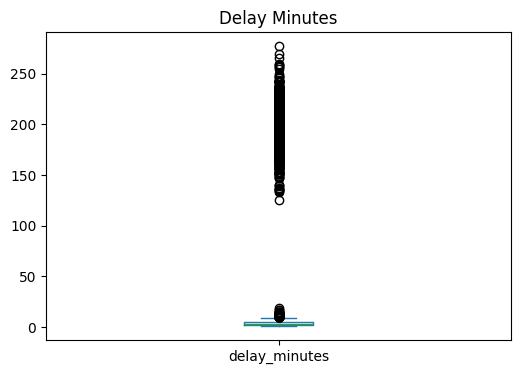

In [13]:
arrived = flights[flights["status"] == "Delayed"].copy()
arrived["delay_minutes"] = (arrived["actual_arrival"] - arrived["scheduled_arrival"]).dt.total_seconds() / 60
arrived["delay_minutes"].plot(kind="box", figsize=(6, 4), title="Delay Minutes")
plt.show()

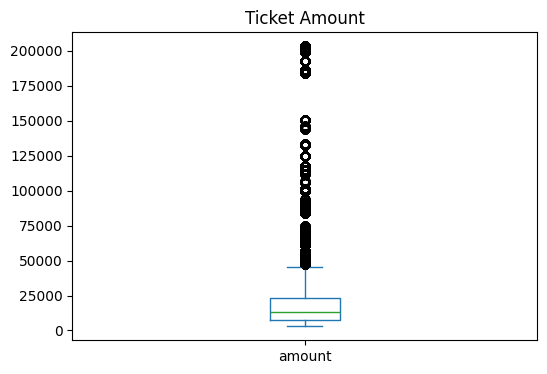

In [14]:
tf["amount"].plot(kind="box", figsize=(6, 4), title="Ticket Amount")
plt.show()

Correlation with Overall Rating:
inflight_entertainment    0.511
food_beverages            0.417
seat_comfort              0.383
staff_service             0.353
Name: overall_rating, dtype: float64


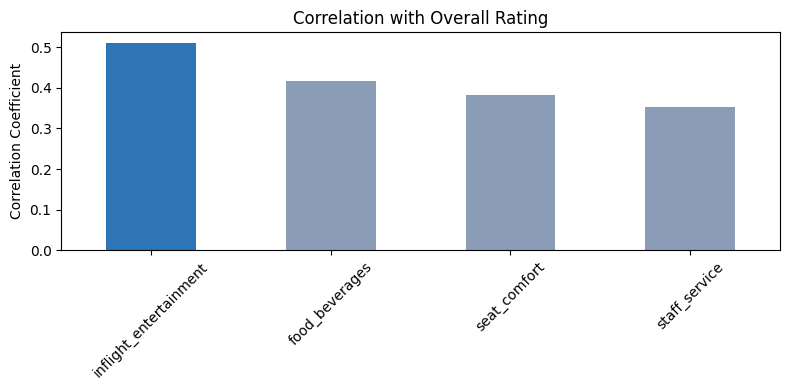

In [15]:
# Correlation Between Categories And Overall Rating

cols = ["seat_comfort", "staff_service", "food_beverages", "inflight_entertainment", "overall_rating"]
corr = reviews[cols].corr()["overall_rating"].drop("overall_rating").sort_values(ascending=False)

print("Correlation with Overall Rating:")
print(corr.round(3))

plt.figure(figsize=(8, 4))
corr.plot(kind="bar", color=["#2E75B6" if v == corr.max() else "#8B9CB6" for v in corr])
plt.title("Correlation with Overall Rating")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Remove Timezone From Datetime Columns
for col in ["scheduled_departure", "scheduled_arrival", "actual_departure", "actual_arrival"]:
    if flights[col].dtype == "datetime64[ns, UTC]" or hasattr(flights[col].dt, "tz"):
        flights[col] = flights[col].dt.tz_localize(None)

if bookings["book_date"].dtype != "datetime64[ns]":
    bookings["book_date"] = bookings["book_date"].dt.tz_localize(None)

In [19]:
# Export Each Table To Separate File
tables = {
    "aircrafts_data":  aircrafts,
    "airports_data":   airports,
    "bookings":        bookings,
    "boarding_passes": boarding,
    "flights":         flights,
    "tickets":         tickets,
    "ticket_flights":  tf,
    "seats":           seats,
    "reviews":         reviews
}

for name, df in tables.items():
    filename = f"{name}.xlsx"
    df.to_excel(filename, index=False)
    files.download(filename)
    print(f"✓ {name} — {len(df):,} rows")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ aircrafts_data — 9 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ seats — 1,339 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ reviews — 1,500 rows
